# Learn a line, predict a range, check its coverage

A sensor reading $y$ depends on an input $x$. We will learn a straight line,
put a range around its prediction, and check how often new readings fall
inside their ranges.

This is Bayesian linear regression with a Gaussian prior and Gaussian error,
as in Bishop's *Pattern Recognition and Machine Learning*, Section 3.3.
The noise level is fixed for this example.

## 1. Start with a model

Our model is

$$y=w_0+w_1x+\varepsilon.$$

We do not know the intercept $w_0$ or slope $w_1$. Give each a Gaussian prior
with mean 0 and standard deviation 2. Assume independent Gaussian measurement
noise with standard deviation 0.5.

In Bishop's notation,

$$
\mathbf w\sim\mathcal N(\mathbf0,\alpha^{-1}I),\qquad
\varepsilon\sim\mathcal N(0,\beta^{-1}),\qquad
\alpha=0.25,\quad\beta=4.
$$

Here $\alpha$ and $\beta$ are inverse variances. Keep both fixed.
Generate 20 training pairs from a pretend sensor so the example runs anywhere.


In [1]:
import math
from statistics import NormalDist
import numpy as np
import matplotlib.pyplot as plt

TEST_COUNT = 10_000       # choose before looking at test results
FAILURE_CHANCE = 0.05     # for the separate coverage check
alpha, beta = 0.25, 4.0

train_rng, test_rng = [
    np.random.default_rng(s)
    for s in np.random.SeedSequence(20260919).spawn(2)
]

def sensor(rng, n):
    x = rng.uniform(-1, 1, n)
    y = 1 + 2*x + rng.normal(0, 0.5, n)
    return x, y

def features(x):
    x = np.atleast_1d(x)
    return np.column_stack([np.ones(len(x)), x])

x_train, y_train = sensor(train_rng, 20)
Phi = features(x_train)


## 2. Learn which lines are plausible

After seeing the data, the coefficients still have a Gaussian distribution.
Its mean $m$ gives our estimated intercept and slope; its covariance $S$
describes their remaining uncertainty:

$$
S=(\alpha I+\beta\Phi^\top\Phi)^{-1},
\qquad m=\beta S\Phi^\top y.
$$

Each row of $\Phi$ is $[1,x_i]$. These are direct calculation rules, with no
sampling approximation required.


In [2]:
precision = alpha*np.eye(2) + beta*Phi.T@Phi
S = np.linalg.solve(precision, np.eye(2))
m = np.linalg.solve(precision, beta*Phi.T@y_train)
print(f"Estimated line: y = {m[0]:.3f} + {m[1]:.3f} x")


Estimated line: y = 1.159 + 1.916 x


The fitted line is **$y\approx1.159+1.916x$**.
The distribution $\mathcal N(m,S)$ is our *posterior*: what we believe about
the coefficients after learning from the observations.

## 3. Predict a new reading

At a new input, write $\phi(x)=[1,x]^\top$. The next reading has the
*posterior predictive distribution*

$$
y_{\rm new}\mid x,\text{data}\sim
\mathcal N\!\left(\phi(x)^\top m,\;
\underbrace{\beta^{-1}}_{\text{new measurement noise}}
+\underbrace{\phi(x)^\top S\phi(x)}_{\text{uncertainty about the line}}\right).
$$

Both variance terms matter. A range for the mean line alone would leave out
the noise in the next reading.

Take the middle 99% of this Gaussian: its mean plus or minus
$2.576$ predictive standard deviations.
[Bishop's calculation](https://www.microsoft.com/en-us/research/wp-content/uploads/2016/05/prml-slides-3.pdf).


In [3]:
z = NormalDist().inv_cdf(0.995)

def predict(x):
    F = features(x)
    mean = F@m
    line_variance = np.sum((F@S)*F, axis=1)
    prediction_sd = np.sqrt(1/beta + line_variance)
    return mean, np.sqrt(line_variance), prediction_sd

mean, line_sd, prediction_sd = predict([0.5])
low, high = mean-z*prediction_sd, mean+z*prediction_sd
print(f"At x = 0.5, predict {mean[0]:.3f}")
print(f"99% prediction interval: [{low[0]:.3f}, {high[0]:.3f}]")


At x = 0.5, predict 2.117
99% prediction interval: [0.777, 3.457]


At **$x=0.5$**, the prediction is **2.117** and the interval is about
**[0.777, 3.457]**. The interval changes with $x$.

The darker band below shows uncertainty about the mean line. The wider,
lighter band includes the variation in new readings. Each vertical slice
shows an interval at that input.


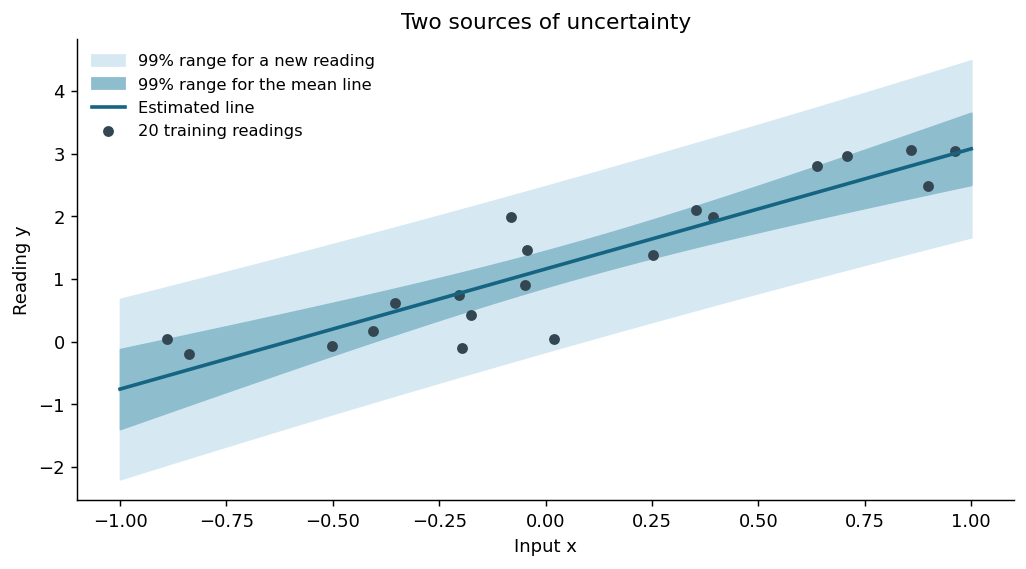

In [4]:
grid = np.linspace(-1, 1, 250)
center, line_sd, prediction_sd = predict(grid)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.fill_between(grid, center-z*prediction_sd, center+z*prediction_sd,
                color="#d6e9f3", label="99% range for a new reading")
ax.fill_between(grid, center-z*line_sd, center+z*line_sd,
                color="#8ebdce", label="99% range for the mean line")
ax.plot(grid, center, color="#156582", lw=2, label="Estimated line")
ax.scatter(x_train, y_train, color="#334652", s=25, label="20 training readings")
ax.set(xlabel="Input x", ylabel="Reading y", title="Two sources of uncertainty")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout()
plt.show()


## 4. Check coverage on fresh pairs

Freeze the fitted prediction rule. For each new input, form its interval
and check whether its observed output lands inside. Do not refit during this
check.

The test inputs use the same distribution as future inputs: uniform on
$[-1,1]$. Here the sensor is simulated. For a real application, use new
measurements from the actual process.


In [5]:
x_test, y_test = sensor(test_rng, TEST_COUNT)
center, _, prediction_sd = predict(x_test)
inside = np.abs(y_test-center) <= z*prediction_sd
hits = int(inside.sum())
coverage = hits / TEST_COUNT
print(f"Inside their prediction intervals: {hits:,} of {TEST_COUNT:,}")
print(f"Measured coverage: {100*coverage:.2f}%")


Inside their prediction intervals: 9,902 of 10,000
Measured coverage: 99.02%


**9,902 of 10,000** readings are inside: **99.02%**.
The model's 99% was a prediction under its assumptions. This is a separate
measurement of how often the intervals work.

## 5. Make allowance for sampling error

Hoeffding gives a one-sided allowance of

$$
\sqrt{\frac{\log(1/0.05)}{2\times10{,}000}}
\approx0.01224
\quad\text{(1.224 percentage points).}
$$

Subtract it from measured coverage. Rounding the result downward:

> **With 95% confidence, this prediction rule covers at least 97.7% of
> new input–output pairs from the same population.**


In [6]:
allowance = math.sqrt(math.log(1/FAILURE_CHANCE) / (2*TEST_COUNT))
lower_bound = max(0, coverage-allowance)
reported_percent = math.floor(1000*lower_bound) / 10
print(f"Hoeffding allowance: {100*allowance:.3f} percentage points")
print(f"With 95% confidence, overall coverage is at least {reported_percent:.1f}%.")


Hoeffding allowance: 1.224 percentage points
With 95% confidence, overall coverage is at least 97.7%.


This statement requires independent test pairs, the same population for
future predictions, and a prediction rule and test count fixed before
checking outcomes. It remains valid even if the Bayesian model is wrong.
It measures coverage averaged over the input population; it does not certify
every input value separately.
[Hoeffding reference](https://www.cs.rpi.edu/academics/courses/spring06/random/hoefding.pdf).

The Bayesian calculation supplies the intervals. Independent observations
and Hoeffding supply a defensible coverage statement. Four times as many
test pairs halves the sampling allowance; changing the prediction rule
requires a fresh check.
